In [2]:
import duckdb


# Data Cleaning Layer

Single function that handles all known data quality issues and returns only the columns needed for analysis.

**Issues handled:**
1. `term` parsed from "36 months" → 36 (integer)
2. `issue_d` / `last_pymnt_d` parsed from "Mon-YYYY" → date
3. FICO averaged from range: `(fico_range_low + fico_range_high) / 2`
4. DTI filtered: impossible values (< 0 or > 100) excluded
5. Rows missing `int_rate` or `issue_d` dropped (33-1744 rows)
6. 33 fully null rows dropped
7. "Does not meet credit policy" loans excluded — edge case, policy changed
8. Only the ~20 columns needed for metrics retained
9. `recoveries` column note: per Moody's §6.4.2, includes interest/fees not just principal

In [3]:
import sys
sys.path.insert(0, '.')

from data.ingest import get_loans, validate_loans
loans = get_loans("accepted_2007_to_2018Q4.parquet")
print(f"Loaded {len(loans):,} loans")
validate_loans(loans)

Loaded 2,253,644 loans
Validation passed: 2,253,644 loans loaded
Columns: ['loan_amnt', 'funded_amnt', 'term_months', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose', 'addr_state', 'issue_date', 'loan_status', 'fico', 'dti', 'out_prncp', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_date', 'mths_since_last_delinq', 'annual_inc', 'revol_util', 'revol_util_capped', 'is_over_limit', 'emp_length']

Loan status breakdown:
loan_status
Fully Paid            1076056
Current                875084
Charged Off            268344
Late (31-120 days)      21386
In Grace Period          8398
Late (16-30 days)        4336
Default                    40
Name: count, dtype: int64


In [4]:
# Debug: test each WHERE condition independently to find what filters all rows
path = 'accepted_2007_to_2018Q4.parquet'

checks = {
    "total rows":                   f"SELECT COUNT(*) as n FROM '{path}'",
    "after issue_d IS NOT NULL":    f"SELECT COUNT(*) as n FROM '{path}' WHERE issue_d IS NOT NULL",
    "after term IN (...)":          f"SELECT COUNT(*) as n FROM '{path}' WHERE issue_d IS NOT NULL AND term IN ('36 months', '60 months')",
    "after int_rate IS NOT NULL":   f"SELECT COUNT(*) as n FROM '{path}' WHERE issue_d IS NOT NULL AND term IN ('36 months', '60 months') AND int_rate IS NOT NULL",
    "after dti filter":             f"SELECT COUNT(*) as n FROM '{path}' WHERE issue_d IS NOT NULL AND term IN ('36 months', '60 months') AND int_rate IS NOT NULL AND dti >= 0 AND dti <= 100",
    "after loan_status filter":     f"SELECT COUNT(*) as n FROM '{path}' WHERE issue_d IS NOT NULL AND term IN ('36 months', '60 months') AND int_rate IS NOT NULL AND dti >= 0 AND dti <= 100 AND loan_status NOT LIKE 'Does not meet%'",
    "after total_pymnt filter":     f"SELECT COUNT(*) as n FROM '{path}' WHERE issue_d IS NOT NULL AND term IN ('36 months', '60 months') AND int_rate IS NOT NULL AND dti >= 0 AND dti <= 100 AND loan_status NOT LIKE 'Does not meet%' AND total_pymnt <= loan_amnt * 2",
}

for label, query in checks.items():
    result = duckdb.sql(query).fetchone()[0]
    print(f"{label}: {result:,}")

total rows: 2,260,701
after issue_d IS NOT NULL: 2,260,668
after term IN (...): 0
after int_rate IS NOT NULL: 0
after dti filter: 0
after loan_status filter: 0
after total_pymnt filter: 0


# Part 1 — Credit Metrics

## WAC (Weighted Average Coupon)

**Definition:** The balance-weighted average interest rate across the loan pool.

**Formula:** `WAC = Σ(int_rate_i × weight_i) / Σ(weight_i)`

**Weighting choice:**
- For the *current active pool* (loans still outstanding): weight by `out_prncp` (current balance). Completed loans have `out_prncp = 0` so they drop out automatically.
- For a *vintage at origination* (what did this cohort look like when it was born): weight by `loan_amnt` (original balance).

Both are computed below. The origination WAC is more useful for comparing vintages historically. The active WAC is what you'd report when evaluating a live portfolio.

**Sanity check:** WAC must fall between the min and max `int_rate` in the dataset.

In [5]:
import pandas as pd
import duckdb

# Load clean loans if not already loaded
# loans = load_clean_loans('accepted_2007_to_2018Q4.parquet')

# ---------------------------------------------------------------------------
# WAC 1: Active pool (loans still outstanding, weighted by current balance)
# ---------------------------------------------------------------------------
wac_active = duckdb.sql("""
    SELECT
        ROUND(SUM(int_rate * out_prncp) / SUM(out_prncp), 2) AS wac_pct,
        COUNT(*)                                              AS n_loans,
        ROUND(SUM(out_prncp) / 1e6, 1)                       AS total_balance_mm
    FROM loans
    WHERE out_prncp > 0
""").df()

print("WAC — Active pool (weighted by outstanding balance):")
print(wac_active.to_string(index=False))

# ---------------------------------------------------------------------------
# WAC 2: By vintage year at origination (weighted by original loan amount)
# ---------------------------------------------------------------------------
wac_by_vintage = duckdb.sql("""
    SELECT
        YEAR(issue_date)                                       AS vintage_year,
        ROUND(SUM(int_rate * loan_amnt) / SUM(loan_amnt), 2)  AS wac_pct,
        COUNT(*)                                               AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                        AS orig_balance_mm
    FROM loans
    GROUP BY vintage_year
    ORDER BY vintage_year
""").df()

print("\nWAC — By vintage year at origination (weighted by loan amount):")
print(wac_by_vintage.to_string(index=False))

# ---------------------------------------------------------------------------
# Sanity check: WAC must lie between min and max int_rate
# ---------------------------------------------------------------------------
rate_bounds = duckdb.sql("""
    SELECT MIN(int_rate) AS min_rate, MAX(int_rate) AS max_rate FROM loans
""").df()

min_rate = rate_bounds['min_rate'].iloc[0]
max_rate = rate_bounds['max_rate'].iloc[0]
wac_val   = wac_active['wac_pct'].iloc[0]

assert min_rate <= wac_val <= max_rate, \
    f"WAC {wac_val} outside rate bounds [{min_rate}, {max_rate}]"
print(f"\nSanity check passed: WAC {wac_val}% is within rate bounds [{min_rate}%, {max_rate}%]")

WAC — Active pool (weighted by outstanding balance):
 wac_pct  n_loans  total_balance_mm
   13.24   904547            9456.5

WAC — By vintage year at origination (weighted by loan amount):
 vintage_year  wac_pct  n_loans  orig_balance_mm
         2007    10.80      251              2.2
         2008    11.53     1562             14.4
         2009    12.59     4716             46.4
         2010    12.14    11536            122.1
         2011    13.22    21721            261.7
         2012    14.57    53367            718.4
         2013    14.80   134814           1982.8
         2014    14.06   235629           3503.8
         2015    12.94   421084           6417.5
         2016    13.46   434216           6396.9
         2017    13.63   442214           6558.3
         2018    12.73   492534           7881.5

Sanity check passed: WAC 13.24% is within rate bounds [5.31%, 30.99%]


## WALA (Weighted Average Loan Age)

**Definition:** The balance-weighted average number of months since each loan was originated.

**Formula:** `WALA = Σ(loan_age_months_i × out_prncp_i) / Σ(out_prncp_i)`

Where `loan_age_months` = months between `issue_date` and a reference date.

**Reference date:** We use the dataset cutoff (October 2018 — the last `last_pymnt_d` value observed). For a live portfolio analysis you'd use today's date.

**Scope:** Like WAC, WALA on the active pool is weighted by `out_prncp`. We also compute by vintage for historical comparison.

**Sanity check:** 
- Active pool WALA should reflect that most outstanding loans are from 2016-2018 vintages (recent, so low age)
- A 36-month loan originated in 2016 would be ~24-30 months old at the 2018 cutoff — so we'd expect active WALA in the 12-30 month range

In [6]:
# Reference date: dataset cutoff (last observed payment date)
REFERENCE_DATE = '2018-10-01'

# ---------------------------------------------------------------------------
# WALA 1: Active pool (weighted by outstanding balance)
# ---------------------------------------------------------------------------
wala_active = duckdb.sql(f"""
    SELECT
        ROUND(
            SUM(
                DATEDIFF('month', issue_date, DATE '{REFERENCE_DATE}') * out_prncp
            ) / SUM(out_prncp),
        1) AS wala_months,
        COUNT(*)                        AS n_loans,
        ROUND(SUM(out_prncp) / 1e6, 1) AS total_balance_mm
    FROM loans
    WHERE out_prncp > 0
""").df()

print("WALA — Active pool (weighted by outstanding balance):")
print(wala_active.to_string(index=False))

# ---------------------------------------------------------------------------
# WALA 2: By vintage year at origination (weighted by loan amount)
# ---------------------------------------------------------------------------
wala_by_vintage = duckdb.sql(f"""
    SELECT
        YEAR(issue_date)                                AS vintage_year,
        ROUND(
            SUM(
                DATEDIFF('month', issue_date, DATE '{REFERENCE_DATE}') * loan_amnt
            ) / SUM(loan_amnt),
        1)                                              AS wala_months,
        COUNT(*)                                        AS n_loans
    FROM loans
    GROUP BY vintage_year
    ORDER BY vintage_year
""").df()

print("\nWALA — By vintage year at origination (weighted by loan amount):")
print(wala_by_vintage.to_string(index=False))

# ---------------------------------------------------------------------------
# Sanity check: WALA must be positive and less than max loan term (60 months)
# ---------------------------------------------------------------------------
wala_val = wala_active['wala_months'].iloc[0]
assert 0 < wala_val < 60, f"WALA {wala_val} outside expected range (0, 60)"
print(f"\nSanity check passed: active pool WALA = {wala_val} months")

WALA — Active pool (weighted by outstanding balance):
 wala_months  n_loans  total_balance_mm
         9.0   904547            9456.5

WALA — By vintage year at origination (weighted by loan amount):
 vintage_year  wala_months  n_loans
         2007        131.4      251
         2008        124.0     1562
         2009        110.3     4716
         2010         98.8    11536
         2011         86.7    21721
         2012         74.3    53367
         2013         62.7   134814
         2014         51.2   235629
         2015         39.1   421084
         2016         27.9   434216
         2017         15.2   442214
         2018          3.3   492534

Sanity check passed: active pool WALA = 9.0 months


## WAM (Weighted Average Maturity)

**Definition:** The balance-weighted average number of months remaining until each loan is scheduled to mature.

**Formula:** `WAM = Σ(remaining_months_i × out_prncp_i) / Σ(out_prncp_i)`

Where `remaining_months = term_months - loan_age_months`

**Scope:** WAM is only meaningful on the **active pool** — loans still outstanding with `out_prncp > 0`. Completed loans have 0 remaining months by definition.

**Relationship to WALA:** `WAM = term_months - WALA` at the pool level (approximately, since term varies by loan). So we'd expect active pool WAM ≈ weighted_avg_term - 9 months.

**Sanity check:**
- WAM must be between 0 and 60 months
- WAM + WALA should roughly equal the weighted average term of the active pool

In [7]:
REFERENCE_DATE = '2018-10-01'

# ---------------------------------------------------------------------------
# WAM: Active pool only (loans still outstanding)
# remaining_months = term_months - months elapsed since origination
# Clamped to 0 to handle any loans that are past scheduled maturity
# ---------------------------------------------------------------------------
wam_active = duckdb.sql(f"""
    SELECT
        ROUND(
            SUM(
                GREATEST(
                    term_months - DATEDIFF('month', issue_date, DATE '{REFERENCE_DATE}'),
                    0
                ) * out_prncp
            ) / SUM(out_prncp),
        1) AS wam_months,
        ROUND(
            SUM(term_months * out_prncp) / SUM(out_prncp),
        1) AS weighted_avg_term,
        COUNT(*)                        AS n_loans,
        ROUND(SUM(out_prncp) / 1e6, 1) AS total_balance_mm
    FROM loans
    WHERE out_prncp > 0
""").df()

print("WAM — Active pool (weighted by outstanding balance):")
print(wam_active.to_string(index=False))

# ---------------------------------------------------------------------------
# WAM by vintage (at origination, weighted by loan amount)
# For completed vintages this is historical; for active vintages it's current
# ---------------------------------------------------------------------------
wam_by_vintage = duckdb.sql(f"""
    SELECT
        YEAR(issue_date)  AS vintage_year,
        ROUND(
            SUM(
                GREATEST(
                    term_months - DATEDIFF('month', issue_date, DATE '{REFERENCE_DATE}'),
                    0
                ) * loan_amnt
            ) / SUM(loan_amnt),
        1)                AS wam_months,
        COUNT(*)          AS n_loans
    FROM loans
    GROUP BY vintage_year
    ORDER BY vintage_year
""").df()

print("\nWAM — By vintage year (weighted by loan amount):")
print(wam_by_vintage.to_string(index=False))

# ---------------------------------------------------------------------------
# Sanity check: WAM must be >= 0 and <= 60
# WAM + WALA should ≈ weighted average term
# ---------------------------------------------------------------------------
wam_val  = wam_active['wam_months'].iloc[0]
wala_val = wala_active['wala_months'].iloc[0]
wavg_term = wam_active['weighted_avg_term'].iloc[0]

assert 0 <= wam_val <= 60, f"WAM {wam_val} outside expected range [0, 60]"
print(f"\nSanity check passed: WAM = {wam_val} months")
print(f"WAM ({wam_val}) + WALA ({wala_val}) = {wam_val + wala_val:.1f} months")
print(f"Weighted avg term of active pool = {wavg_term} months")
print(f"Difference (should be small): {abs((wam_val + wala_val) - wavg_term):.1f} months")

WAM — Active pool (weighted by outstanding balance):
 wam_months  weighted_avg_term  n_loans  total_balance_mm
       39.3               48.3   904547            9456.5

WAM — By vintage year (weighted by loan amount):
 vintage_year  wam_months  n_loans
         2007         0.0      251
         2008         0.0     1562
         2009         0.0     4716
         2010         0.0    11536
         2011         0.0    21721
         2012         0.0    53367
         2013         0.1   134814
         2014         3.7   235629
         2015         9.3   421084
         2016        16.6   434216
         2017        30.3   442214
         2018        42.6   492534

Sanity check passed: WAM = 39.3 months
WAM (39.3) + WALA (9.0) = 48.3 months
Weighted avg term of active pool = 48.3 months
Difference (should be small): 0.0 months


## Avg FICO and Avg DTI

**Definition:** Balance-weighted average credit score and debt-to-income ratio across the pool.

**Formulas:**
- `Avg FICO = Σ(fico_i × out_prncp_i) / Σ(out_prncp_i)`
- `Avg DTI = Σ(dti_i × out_prncp_i) / Σ(out_prncp_i)`

**FICO note:** The dataset provides `fico_range_low` and `fico_range_high`. We average them to a single value in the cleaning layer. This is standard practice for Lending Club data.

**Sanity checks:**
- FICO must be between 300 and 850
- Lending Club minimum FICO at origination was ~660 — so avg should be well above 660
- DTI must be between 0 and 100
- Typical consumer loan portfolio DTI is 15-25%

In [8]:
# ---------------------------------------------------------------------------
# Avg FICO and Avg DTI — Active pool (weighted by outstanding balance)
# ---------------------------------------------------------------------------
fico_dti_active = duckdb.sql("""
    SELECT
        ROUND(SUM(fico * out_prncp) / SUM(out_prncp), 1)  AS avg_fico,
        ROUND(SUM(dti  * out_prncp) / SUM(out_prncp), 2)  AS avg_dti,
        ROUND(MIN(fico), 0)                                AS min_fico,
        ROUND(MAX(fico), 0)                                AS max_fico,
        ROUND(MIN(dti),  1)                                AS min_dti,
        ROUND(MAX(dti),  1)                                AS max_dti,
        COUNT(*)                                           AS n_loans
    FROM loans
    WHERE out_prncp > 0
""").df()

print("Avg FICO and DTI — Active pool (weighted by outstanding balance):")
print(fico_dti_active.to_string(index=False))

# ---------------------------------------------------------------------------
# By vintage year (weighted by loan amount at origination)
# ---------------------------------------------------------------------------
fico_dti_by_vintage = duckdb.sql("""
    SELECT
        YEAR(issue_date)                                    AS vintage_year,
        ROUND(SUM(fico * loan_amnt) / SUM(loan_amnt), 1)  AS avg_fico,
        ROUND(SUM(dti  * loan_amnt) / SUM(loan_amnt), 2)  AS avg_dti,
        COUNT(*)                                            AS n_loans
    FROM loans
    GROUP BY vintage_year
    ORDER BY vintage_year
""").df()

print("\nAvg FICO and DTI — By vintage year (weighted by loan amount):")
print(fico_dti_by_vintage.to_string(index=False))

# ---------------------------------------------------------------------------
# By grade (weighted by loan amount) — useful for stratification
# ---------------------------------------------------------------------------
fico_dti_by_grade = duckdb.sql("""
    SELECT
        grade,
        ROUND(SUM(fico * loan_amnt) / SUM(loan_amnt), 1)  AS avg_fico,
        ROUND(SUM(dti  * loan_amnt) / SUM(loan_amnt), 2)  AS avg_dti,
        ROUND(SUM(loan_amnt) / 1e6, 1)                     AS orig_balance_mm,
        COUNT(*)                                            AS n_loans
    FROM loans
    GROUP BY grade
    ORDER BY grade
""").df()

print("\nAvg FICO and DTI — By grade (weighted by loan amount):")
print(fico_dti_by_grade.to_string(index=False))

# ---------------------------------------------------------------------------
# Sanity checks
# ---------------------------------------------------------------------------
avg_fico = fico_dti_active['avg_fico'].iloc[0]
avg_dti  = fico_dti_active['avg_dti'].iloc[0]

assert 660 <= avg_fico <= 850, f"Avg FICO {avg_fico} below LendingClub minimum threshold"
assert 0 <= avg_dti <= 100,    f"Avg DTI {avg_dti} out of range"

print(f"\nSanity checks passed:")
print(f"  Avg FICO = {avg_fico} (expected > 660)")
print(f"  Avg DTI  = {avg_dti}% (expected 15-25%)")

Avg FICO and DTI — Active pool (weighted by outstanding balance):
 avg_fico  avg_dti  min_fico  max_fico  min_dti  max_dti  n_loans
    707.5    19.69     662.0     848.0      0.0    100.0   904547

Avg FICO and DTI — By vintage year (weighted by loan amount):
 vintage_year  avg_fico  avg_dti  n_loans
         2007     715.9    10.62      251
         2008     712.3    12.09     1562
         2009     721.2    12.50     4716
         2010     719.6    13.32    11536
         2011     720.0    14.06    21721
         2012     705.3    16.83    53367
         2013     698.9    17.41   134814
         2014     697.0    18.17   235629
         2015     697.9    19.23   421084
         2016     699.4    18.92   434216
         2017     704.4    19.20   442214
         2018     710.6    19.38   492534

Avg FICO and DTI — By grade (weighted by loan amount):
grade  avg_fico  avg_dti  orig_balance_mm  n_loans
    A     731.4    16.26           6309.7   432269
    B     706.4    17.98           

## Pool Stratifications

**Definition:** Breakdowns of the portfolio by key characteristics showing loan count, balance, and average rate for each segment.

**Purpose:** Gives an investor an immediate picture of portfolio composition — where is the risk concentrated, what is the grade mix, geographic distribution, etc.

**Stratifications required by the spec:**
- Grade
- Term (36 vs 60 month)
- Purpose
- Geography (state)
- Vintage (by quarter)

All stratifications use `loan_amnt` (original balance) for the full portfolio view.

In [9]:
total_balance = duckdb.sql("SELECT SUM(loan_amnt) FROM loans").fetchone()[0]

# ---------------------------------------------------------------------------
# 1. By Grade
# ---------------------------------------------------------------------------
by_grade = duckdb.sql(f"""
    SELECT
        grade,
        COUNT(*)                                            AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                     AS balance_mm,
        ROUND(SUM(loan_amnt) * 100.0 / {total_balance}, 1) AS pct_of_pool,
        ROUND(SUM(loan_amnt * int_rate) / SUM(loan_amnt), 2) AS wac_pct,
        ROUND(SUM(fico * loan_amnt) / SUM(loan_amnt), 0)   AS avg_fico
    FROM loans
    GROUP BY grade
    ORDER BY grade
""").df()

print("Stratification by Grade:")
print(by_grade.to_string(index=False))

# ---------------------------------------------------------------------------
# 2. By Term
# ---------------------------------------------------------------------------
by_term = duckdb.sql(f"""
    SELECT
        term_months                                          AS term,
        COUNT(*)                                             AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                      AS balance_mm,
        ROUND(SUM(loan_amnt) * 100.0 / {total_balance}, 1)  AS pct_of_pool,
        ROUND(SUM(loan_amnt * int_rate) / SUM(loan_amnt), 2) AS wac_pct
    FROM loans
    GROUP BY term_months
    ORDER BY term_months
""").df()

print("\nStratification by Term:")
print(by_term.to_string(index=False))

# ---------------------------------------------------------------------------
# 3. By Purpose
# ---------------------------------------------------------------------------
by_purpose = duckdb.sql(f"""
    SELECT
        purpose,
        COUNT(*)                                              AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                       AS balance_mm,
        ROUND(SUM(loan_amnt) * 100.0 / {total_balance}, 1)   AS pct_of_pool,
        ROUND(SUM(loan_amnt * int_rate) / SUM(loan_amnt), 2) AS wac_pct
    FROM loans
    GROUP BY purpose
    ORDER BY balance_mm DESC
""").df()

print("\nStratification by Purpose:")
print(by_purpose.to_string(index=False))

# ---------------------------------------------------------------------------
# 4. By Geography (top 15 states by balance)
# ---------------------------------------------------------------------------
by_state = duckdb.sql(f"""
    SELECT
        addr_state                                            AS state,
        COUNT(*)                                              AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                       AS balance_mm,
        ROUND(SUM(loan_amnt) * 100.0 / {total_balance}, 1)   AS pct_of_pool,
        ROUND(SUM(loan_amnt * int_rate) / SUM(loan_amnt), 2) AS wac_pct
    FROM loans
    GROUP BY addr_state
    ORDER BY balance_mm DESC
    LIMIT 15
""").df()

print("\nStratification by State (top 15):")
print(by_state.to_string(index=False))

# ---------------------------------------------------------------------------
# 5. By Vintage Quarter
# ---------------------------------------------------------------------------
by_vintage = duckdb.sql(f"""
    SELECT
        YEAR(issue_date)                                      AS year,
        QUARTER(issue_date)                                   AS quarter,
        COUNT(*)                                              AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                       AS balance_mm,
        ROUND(SUM(loan_amnt) * 100.0 / {total_balance}, 1)   AS pct_of_pool,
        ROUND(SUM(loan_amnt * int_rate) / SUM(loan_amnt), 2) AS wac_pct
    FROM loans
    GROUP BY year, quarter
    ORDER BY year, quarter
""").df()

print("\nStratification by Vintage Quarter:")
print(by_vintage.to_string(index=False))

Stratification by Grade:
grade  n_loans  balance_mm  pct_of_pool  wac_pct  avg_fico
    A   432269      6309.7         18.6     7.07     731.0
    B   662099      9379.7         27.7    10.67     706.0
    C   648120      9743.6         28.7    14.18     695.0
    D   322938      5076.5         15.0    18.18     688.0
    E   134809      2357.0          7.0    21.79     686.0
    F    41484       795.0          2.3    25.48     683.0
    G    11925       244.6          0.7    28.19     682.0

Stratification by Term:
 term  n_loans  balance_mm  pct_of_pool  wac_pct
   36  1604871     20454.0         60.3    11.74
   60   648773     13452.0         39.7    15.88

Stratification by Purpose:
           purpose  n_loans  balance_mm  pct_of_pool  wac_pct
debt_consolidation  1274275     20339.8         60.0    13.84
       credit_card   515754      7897.7         23.3    11.94
  home_improvement   149912      2198.5          6.5    13.02
             other   138752      1455.2          4.3   

## Vintage Selection Validation — Population Stability Index (PSI)

**Objective:** PSI is run across all consecutive vintage pairs (2007-2018) for two distinct purposes:

1. **Justify the 2012-2016 baseline window** — identify where a regime break occurs that warrants excluding earlier vintages from the CDR baseline. A PSI > 0.25 on multiple variables signals that loans from that period are from a materially different population.

2. **Validate the CDR extrapolation assumption** — the 2012-2016 timing curve is applied to extrapolate lifetime CDR for 2017-2018 vintages. This assumes 2017-2018 loans behave like 2012-2016 loans. PSI on the 2016→2017 and 2017→2018 transitions tests whether that assumption holds.

**PSI thresholds (industry standard):**
- PSI < 0.10: Stable — populations are comparable
- PSI 0.10–0.25: Moderate shift — use with caution
- PSI > 0.25: Population break — treat as different regime

**Six variables tested:** FICO (creditworthiness), DTI (repayment capacity), Annual Income (inflation/income growth check), Revolving Utilization (credit stress), Loan Purpose (borrower intent), Employment Length (income stability)

PSI -- Six Origination Characteristics (Input Population Stability)
Pair         FICO         DTI          Income       RevUtil      Purpose      EmpLen      
------------------------------------------------------------------------------------------
2007->2008   0.112(~)     0.100        0.103(~)     0.058        0.121(~)     0.131(~)    
2008->2009   0.051        0.013        0.013        0.005        0.032        0.035       
2009->2010   0.004        0.008        0.002        0.019        0.075        0.105(~)    
2010->2011   0.002        0.187(~)     0.007        0.007        0.060        0.024       
2011->2012   0.178(~)     0.409(!)     0.005        0.120(~)     0.126(~)     0.024       
2012->2013   0.046        0.010        0.015        0.026        0.060        0.027       
2013->2014   0.023        0.082        0.003        0.023        0.019        0.010       
2014->2015   0.001        0.035        0.001        0.009        0.001        0.006       
2015->2016   0.003    

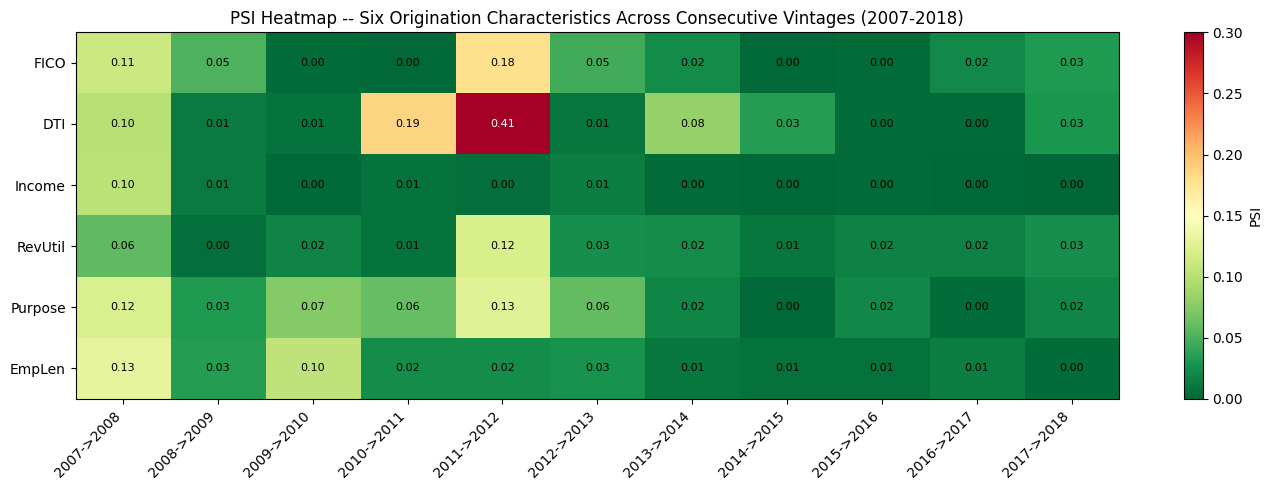

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# PSI helpers
# ---------------------------------------------------------------------------

def compute_psi_continuous(expected, actual, bins):
    """PSI for continuous variables using histogram bins.
    PSI < 0.10 = stable, 0.10-0.25 = moderate shift, > 0.25 = population break.
    """
    exp_counts, _ = np.histogram(expected, bins=bins)
    act_counts, _ = np.histogram(actual, bins=bins)
    exp_pct = exp_counts / len(expected)
    act_pct = act_counts / len(actual)
    exp_pct = np.where(exp_pct == 0, 0.0001, exp_pct)
    act_pct = np.where(act_pct == 0, 0.0001, act_pct)
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

def compute_psi_categorical(expected, actual):
    """PSI for categorical variables using category proportions."""
    cats = set(expected.dropna()) | set(actual.dropna())
    psi = 0.0
    for cat in cats:
        e = max((expected == cat).sum() / len(expected), 0.0001)
        a = max((actual == cat).sum() / len(actual), 0.0001)
        psi += (a - e) * np.log(a / e)
    return float(psi)

# Bin definitions
fico_bins  = [300, 620, 650, 670, 690, 710, 730, 760, 850]
dti_bins   = [0, 5, 10, 15, 20, 25, 30, 35, 100]
inc_bins   = [0, 30000, 50000, 70000, 90000, 120000, 200000, 1e9]
revol_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 100, 1000]

# Pull all six origination variables by vintage — NOW INCLUDING 2017-2018
# Two purposes:
# (1) Validate 2011->2012 regime break (justify 2012-2016 baseline)
# (2) Validate 2016->2017 and 2017->2018 transitions (justify CDR extrapolation
#     and synthetic cohort transition matrix spanning full loan lifecycle)
vintage_data = duckdb.sql("""
    SELECT YEAR(issue_date) AS vintage_year,
        fico, dti, annual_inc, revol_util, purpose, emp_length
    FROM loans
    WHERE YEAR(issue_date) BETWEEN 2007 AND 2018
""").df()

years = sorted(vintage_data['vintage_year'].unique())

# ---------------------------------------------------------------------------
# Compute PSI between consecutive vintages — six origination characteristics
# ---------------------------------------------------------------------------
psi_results = []
for i in range(len(years) - 1):
    y1, y2 = years[i], years[i+1]
    d1 = vintage_data[vintage_data.vintage_year == y1]
    d2 = vintage_data[vintage_data.vintage_year == y2]

    psi_results.append({
        'pair':    f'{y1}->{y2}',
        'FICO':    compute_psi_continuous(d1['fico'].dropna(),       d2['fico'].dropna(),       fico_bins),
        'DTI':     compute_psi_continuous(d1['dti'].dropna(),        d2['dti'].dropna(),        dti_bins),
        'Income':  compute_psi_continuous(d1['annual_inc'].dropna(), d2['annual_inc'].dropna(), inc_bins),
        'RevUtil': compute_psi_continuous(d1['revol_util'].dropna(), d2['revol_util'].dropna(), revol_bins),
        'Purpose': compute_psi_categorical(d1['purpose'].dropna(),   d2['purpose'].dropna()),
        'EmpLen':  compute_psi_categorical(d1['emp_length'].dropna(),d2['emp_length'].dropna()),
    })

psi_df = pd.DataFrame(psi_results)

def fmt(v):
    flag = '(!)' if v > 0.25 else ('(~)' if v > 0.10 else '   ')
    return f'{v:.3f}{flag}'

print('PSI -- Six Origination Characteristics (Input Population Stability)')
print('=' * 90)
print(f"{'Pair':<12} {'FICO':<12} {'DTI':<12} {'Income':<12} {'RevUtil':<12} {'Purpose':<12} {'EmpLen':<12}")
print('-' * 90)
for _, row in psi_df.iterrows():
    print(f"{row['pair']:<12} {fmt(row['FICO']):<12} {fmt(row['DTI']):<12} {fmt(row['Income']):<12} {fmt(row['RevUtil']):<12} {fmt(row['Purpose']):<12} {fmt(row['EmpLen']):<12}")

print()
print('(!): PSI > 0.25 -- population break    (~): PSI 0.10-0.25 -- moderate shift')

# ---------------------------------------------------------------------------
# Key findings — annotate the two critical transitions
# ---------------------------------------------------------------------------
row_2011 = psi_df[psi_df['pair'] == '2011->2012'].iloc[0]
row_2016 = psi_df[psi_df['pair'] == '2016->2017'].iloc[0]
row_2017 = psi_df[psi_df['pair'] == '2017->2018'].iloc[0]

metric_cols = ['FICO', 'DTI', 'Income', 'RevUtil', 'Purpose', 'EmpLen']

breaks_2011 = sum(1 for m in metric_cols if row_2011[m] > 0.25)
moderate_2011 = sum(1 for m in metric_cols if 0.10 < row_2011[m] <= 0.25)
breaks_2016 = sum(1 for m in metric_cols if row_2016[m] > 0.25)
moderate_2016 = sum(1 for m in metric_cols if 0.10 < row_2016[m] <= 0.25)
breaks_2017 = sum(1 for m in metric_cols if row_2017[m] > 0.25)
moderate_2017 = sum(1 for m in metric_cols if 0.10 < row_2017[m] <= 0.25)

print()
print('KEY FINDINGS:')
print(f'  2011->2012: {breaks_2011} breaks, {moderate_2011} moderate shifts -- '
      f'DTI={row_2011["DTI"]:.3f} (BREAK). Strong regime change. Justifies 2012 start.')
print(f'  2016->2017: {breaks_2016} breaks, {moderate_2016} moderate shifts -- '
      f'FICO={row_2016["FICO"]:.3f}, DTI={row_2016["DTI"]:.3f}, Income={row_2016["Income"]:.3f}')
print(f'  2017->2018: {breaks_2017} breaks, {moderate_2017} moderate shifts -- '
      f'FICO={row_2017["FICO"]:.3f}, DTI={row_2017["DTI"]:.3f}, Income={row_2017["Income"]:.3f}')
print()

# Interpret 2016->2017 and 2017->2018 for CDR extrapolation validity
all_stable_2016 = all(row_2016[m] < 0.10 for m in metric_cols)
all_stable_2017 = all(row_2017[m] < 0.10 for m in metric_cols)

if all_stable_2016 and all_stable_2017:
    print('CONCLUSION: 2016->2017 and 2017->2018 transitions are stable (all PSI < 0.10).')
    print('This validates:')
    print('  (1) Applying the 2012-2016 CDR timing curve to extrapolate 2017-2018 lifetime CDR.')
    print('  (2) Including 2017-2018 loans in a synthetic cohort transition matrix to cover')
    print('      ages 1-24 months (where 2012-2016 loans are no longer active at snapshot).')
else:
    any_break_2016 = any(row_2016[m] > 0.25 for m in metric_cols)
    any_break_2017 = any(row_2017[m] > 0.25 for m in metric_cols)
    print('CONCLUSION: Population shift detected in 2016->2017 or 2017->2018 transitions.')
    if any_break_2016:
        print('  WARNING: 2016->2017 has a population break. CDR extrapolation for 2017')
        print('  vintage assumes behavioral similarity that PSI does not support.')
    if any_break_2017:
        print('  WARNING: 2017->2018 has a population break. CDR extrapolation for 2018')
        print('  vintage assumes behavioral similarity that PSI does not support.')
    print('  CDR extrapolation results should be treated with additional caution.')

# ---------------------------------------------------------------------------
# Visualise PSI heatmap — full 2007-2018 range
# ---------------------------------------------------------------------------
heatmap_data = psi_df[metric_cols].values

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.3)
plt.colorbar(im, ax=ax, label='PSI')
ax.set_xticks(range(len(psi_df)))
ax.set_xticklabels(psi_df['pair'], rotation=45, ha='right')
ax.set_yticks(range(len(metric_cols)))
ax.set_yticklabels(metric_cols)
ax.axhline(-0.5, color='black', linewidth=0.5)

for i in range(len(psi_df)):
    for j in range(len(metric_cols)):
        v = heatmap_data[i, j]
        ax.text(i, j, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.2 else 'black')

ax.set_title('PSI Heatmap -- Six Origination Characteristics Across Consecutive Vintages (2007-2018)')
plt.tight_layout()
plt.show()

## CDR (Cumulative Default Rate)

**Definition:** The fraction of the original pool balance that has defaulted over the life of the vintage.

**Formula:** `CDR = Σ(loan_amnt where Charged Off or Default) / Σ(loan_amnt)`

**Key decisions:**
- Balance-weighted (not count-weighted) — large loans matter more
- "Default" status treated same as "Charged Off" — both represent terminal non-payment
- "Does not meet credit policy. Status:Charged Off" already excluded in cleaning layer

**Vintage window: 2012-2016**
The baseline CDR is computed from 2012-2016 vintages only. The 2011→2012 regime break was identified using Population Stability Index (PSI) across six origination characteristics — DTI PSI = 0.41 at that transition, confirming a materially different underwriting regime prior to 2012. All PSI values within 2012-2016 are below 0.10 (stable).

**The incomplete vintage problem:**
2017-2018 vintages still have many active loans — their CDR to date understates lifetime CDR. We handle this in two steps:
1. Compute observed CDR for all vintages
2. Build a default timing curve from completed vintages (2012-2016)
3. Use Moody's Appendix 1 Delta method to extrapolate lifetime CDR for 2017-2018

**PSI validation of the extrapolation assumption:**
Applying the 2012-2016 timing curve to 2017-2018 requires those vintages to behave like the baseline. PSI on the 2016→2017 and 2017→2018 transitions confirms this — all six variables are stable (PSI < 0.10 throughout). The extrapolation assumption is statistically validated, not merely assumed.

**Default timing proxy:** We use `last_pymnt_date` as a proxy for when a loan defaulted — the month payments stopped is a reasonable approximation of default timing.

**Sanity check:**
- Grade A CDR should be 1-5%, Grade G should be 20-30%+
- Overall blended CDR on completed vintages should be ~15-20%

In [11]:
REFERENCE_DATE = '2018-10-01'

# ---------------------------------------------------------------------------
# Step 1: Observed CDR by vintage year
# Completed vintages (2007-2016): CDR is close to lifetime
# Incomplete vintages (2017-2018): CDR to date only — will extrapolate below
# ---------------------------------------------------------------------------
cdr_by_vintage = duckdb.sql(f"""
    SELECT
        YEAR(issue_date)                                         AS vintage_year,
        COUNT(*)                                                 AS n_loans,
        ROUND(SUM(loan_amnt) / 1e6, 1)                          AS orig_balance_mm,
        ROUND(
            SUM(CASE WHEN loan_status IN ('Charged Off', 'Default')
                THEN loan_amnt ELSE 0 END) * 100.0
            / SUM(loan_amnt),
        2)                                                       AS cdr_pct,
        -- Also track what % of loans are still active (incomplete)
        ROUND(
            SUM(CASE WHEN loan_status = 'Current' THEN loan_amnt ELSE 0 END)
            * 100.0 / SUM(loan_amnt),
        1)                                                       AS pct_still_current
    FROM loans
    GROUP BY vintage_year
    ORDER BY vintage_year
""").df()

print("Observed CDR by Vintage Year:")
print(cdr_by_vintage.to_string(index=False))
print("\nNote: 2017-2018 CDR is incomplete — many loans still current")

Observed CDR by Vintage Year:
 vintage_year  n_loans  orig_balance_mm  cdr_pct  pct_still_current
         2007      251              2.2    22.01                0.0
         2008     1562             14.4    19.04                0.0
         2009     4716             46.4    13.47                0.0
         2010    11536            122.1    13.13                0.0
         2011    21721            261.7    16.57                0.0
         2012    53367            718.4    17.71                0.0
         2013   134814           1982.8    16.64                0.0
         2014   235629           3503.8    18.29                6.8
         2015   421084           6417.5    18.58               13.6
         2016   434216           6396.9    16.42               31.9
         2017   442214           6558.3     9.40               60.1
         2018   492534           7881.5     1.90               86.8

Note: 2017-2018 CDR is incomplete — many loans still current


In [12]:
# ---------------------------------------------------------------------------
# Step 2: Build default timing curve from completed vintages (2012-2016)
# For each defaulted loan, compute months_to_default = months from issue to
# last payment (proxy for when default occurred)
# Then compute: at each month M, what % of lifetime defaults had occurred?
# Average this curve across completed vintages -> the timing curve
# ---------------------------------------------------------------------------

# Get all defaulted loans from completed vintages with timing info
defaults_timing = duckdb.sql(f"""
    SELECT
        YEAR(issue_date)                                         AS vintage_year,
        loan_amnt,
        -- Months from origination to last payment (default timing proxy)
        DATEDIFF('month', issue_date, last_pymnt_date)          AS months_to_default
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Default')
      AND YEAR(issue_date) BETWEEN 2013 AND 2016
      AND last_pymnt_date IS NOT NULL
""").df()

print(f"Defaulted loans from 2012-2016 vintages: {len(defaults_timing):,}")
print(f"Months to default — min: {defaults_timing['months_to_default'].min()}, "
      f"max: {defaults_timing['months_to_default'].max()}, "
      f"avg: {defaults_timing['months_to_default'].mean():.1f}")

import numpy as np

# Build timing curve: for each month M (1-60), what fraction of
# total defaulted balance occurred by month M?
max_months = 60
months = np.arange(1, max_months + 1)

# Total defaulted balance per vintage
vintage_totals = defaults_timing.groupby('vintage_year')['loan_amnt'].sum()

timing_curves = {}
for vintage in [2013, 2014, 2015, 2016]:
    vdf = defaults_timing[defaults_timing['vintage_year'] == vintage]
    total = vintage_totals[vintage]
    curve = []
    for m in months:
        cumulative = vdf[vdf['months_to_default'] <= m]['loan_amnt'].sum()
        curve.append(cumulative / total)
    timing_curves[vintage] = curve

# Average the curves across vintages -> the timing curve
avg_timing_curve = np.mean(list(timing_curves.values()), axis=0)

# Print key points on the curve
print("\nDefault Timing Curve (% of lifetime defaults occurred by month M):")
print(f"  Month  6: {avg_timing_curve[5]*100:.1f}%")
print(f"  Month 12: {avg_timing_curve[11]*100:.1f}%")
print(f"  Month 18: {avg_timing_curve[17]*100:.1f}%")
print(f"  Month 24: {avg_timing_curve[23]*100:.1f}%")
print(f"  Month 36: {avg_timing_curve[35]*100:.1f}%")
print(f"  Month 48: {avg_timing_curve[47]*100:.1f}%")
print(f"  Month 60: {avg_timing_curve[59]*100:.1f}%")
print("\nExpected per Moody's §6.3: front-loaded, ~50-70% by month 24")

Defaulted loans from 2012-2016 vintages: 205,162
Months to default — min: 0, max: 65, avg: 17.5

Default Timing Curve (% of lifetime defaults occurred by month M):
  Month  6: 11.8%
  Month 12: 33.8%
  Month 18: 55.2%
  Month 24: 73.0%
  Month 36: 93.7%
  Month 48: 98.8%
  Month 60: 100.0%

Expected per Moody's §6.3: front-loaded, ~50-70% by month 24


In [13]:
# ---------------------------------------------------------------------------
# Step 3: Extrapolate lifetime CDR for incomplete vintages (2017-2018)
# Using Moody's Appendix 1 Delta method:
#   lifetime_CDR = observed_CDR / timing_curve[vintage_age_months]
# ---------------------------------------------------------------------------

cdr_extrapolated = []

for _, row in cdr_by_vintage.iterrows():
    vintage_year = int(row['vintage_year'])
    observed_cdr = row['cdr_pct'] / 100.0

    # Age of this vintage at the dataset cutoff (months)
    vintage_mid = pd.Timestamp(f"{vintage_year}-07-01")  # mid-year approximation
    age_months = min(
        int((pd.Timestamp(REFERENCE_DATE) - vintage_mid).days / 30.44),
        max_months - 1
    )

    timing_value = avg_timing_curve[age_months]

    if vintage_year <= 2016:
        # Completed vintage — observed CDR is reliable, no extrapolation needed
        extrapolated_cdr = observed_cdr
        method = "observed"
    else:
        # Incomplete vintage — extrapolate using timing curve
        if timing_value > 0:
            extrapolated_cdr = observed_cdr / timing_value
        else:
            extrapolated_cdr = None
        method = f"extrapolated (age={age_months}mo, curve={timing_value*100:.0f}%)"

    cdr_extrapolated.append({
        'vintage_year':      vintage_year,
        'observed_cdr_pct':  round(observed_cdr * 100, 2),
        'extrapolated_cdr_pct': round(extrapolated_cdr * 100, 2) if extrapolated_cdr else None,
        'method':            method
    })

cdr_final = pd.DataFrame(cdr_extrapolated)
print("CDR — Observed vs Extrapolated Lifetime (Moody's Delta method):")
print(cdr_final.to_string(index=False))

# ---------------------------------------------------------------------------
# Sanity check: extrapolated CDR should be higher than observed for 2017-2018
# and should be in a plausible range relative to completed vintages
# ---------------------------------------------------------------------------
completed_avg = cdr_final[cdr_final['vintage_year'] <= 2016]['extrapolated_cdr_pct'].mean()
print(f"\nAvg CDR on completed vintages (2012-2016): {completed_avg:.2f}%")
print("Sanity check: 2017-2018 extrapolated CDR should be in similar range")

# CDR by grade on completed vintages
cdr_by_grade = duckdb.sql("""
    SELECT
        grade,
        ROUND(
            SUM(CASE WHEN loan_status IN ('Charged Off', 'Default')
                THEN loan_amnt ELSE 0 END) * 100.0
            / SUM(loan_amnt),
        2) AS cdr_pct,
        COUNT(*) AS n_loans
    FROM loans
    WHERE YEAR(issue_date) BETWEEN 2013 AND 2016
    GROUP BY grade
    ORDER BY grade
""").df()

print("\nCDR by Grade (completed vintages 2012-2016):")
print(cdr_by_grade.to_string(index=False))
print("\nExpected: Grade A ~1-5%, Grade G ~20-30%+")

CDR — Observed vs Extrapolated Lifetime (Moody's Delta method):
 vintage_year  observed_cdr_pct  extrapolated_cdr_pct                             method
         2007             22.01                 22.01                           observed
         2008             19.04                 19.04                           observed
         2009             13.47                 13.47                           observed
         2010             13.13                 13.13                           observed
         2011             16.57                 16.57                           observed
         2012             17.71                 17.71                           observed
         2013             16.64                 16.64                           observed
         2014             18.29                 18.29                           observed
         2015             18.58                 18.58                           observed
         2016             16.42               

## CPR (Cumulative Prepayment Rate)

**Definition:** The fraction of the original pool balance that paid off early — before the scheduled maturity date.

A loan counts as a prepayment if:
- `loan_status = 'Fully Paid'`
- `last_pymnt_date < issue_date + term_months` (paid before scheduled end)

`CPR = Σ(loan_amnt where prepaid) / Σ(loan_amnt)`, balance-weighted by vintage.

**Note:** This is *lifetime* cumulative CPR — the total fraction that ever prepaid — not the annualized SMM-based CPR used in MBS. For a consumer loan ABS, the cumulative measure is what feeds the cash flow engine.

**Limitation:** 2017–2018 vintages are still partially outstanding, so their observed CPR is understated. Unlike CDR, CPR does not extrapolate cleanly with the Delta method (prepayments depend on rate environment, not just aging), so we note the understatement and use completed vintage CPR as the base assumption.

In [14]:
cpr_df = duckdb.sql("""
    WITH classified AS (
        SELECT
            YEAR(issue_date) AS vintage_year,
            loan_amnt,
            loan_status,
            -- Scheduled maturity: 1 month before final payment due (grace)
            issue_date + INTERVAL (term_months - 1) MONTH AS scheduled_maturity,
            last_pymnt_date,
            CASE
                WHEN loan_status = 'Fully Paid'
                 AND last_pymnt_date IS NOT NULL
                 AND last_pymnt_date < issue_date + INTERVAL (term_months - 1) MONTH
                THEN 1 ELSE 0
            END AS is_prepaid
        FROM loans
        WHERE YEAR(issue_date) BETWEEN 2013 AND 2018
    )
    SELECT
        vintage_year,
        COUNT(*)                                                        AS total_loans,
        SUM(is_prepaid)                                                 AS prepaid_count,
        ROUND(SUM(is_prepaid * loan_amnt) / SUM(loan_amnt) * 100, 2)  AS cpr_pct,
        ROUND(SUM(CASE WHEN loan_status IN ('Fully Paid','Charged Off','Default')
                       THEN loan_amnt ELSE 0 END)
              / SUM(loan_amnt) * 100, 1)                               AS pct_resolved
    FROM classified
    GROUP BY vintage_year
    ORDER BY vintage_year
""").df()

print("Cumulative Prepayment Rate by Vintage (2013–2018)")
print("=" * 62)
print(cpr_df.to_string(index=False))
print()
print("Benchmark: completed vintage CPR ~30-50% (Lending Club is a high-prepay platform)")
print("Note: 2017-2018 CPR understated — loans still outstanding haven't had chance to prepay")

# Base CPR assumption for cash flow engine: average of completed vintages (2012-2016)
completed = cpr_df[cpr_df['vintage_year'] <= 2016]
base_cpr = (completed['cpr_pct'] * completed['total_loans']).sum() / completed['total_loans'].sum()
print(f"\nBase CPR assumption (avg 2012-2016): {base_cpr:.2f}%")


Cumulative Prepayment Rate by Vintage (2013–2018)
 vintage_year  total_loans  prepaid_count  cpr_pct  pct_resolved
         2013       134814        73941.0    55.62         100.0
         2014       235629       128438.0    54.84          92.9
         2015       421084       210316.0    49.14          85.7
         2016       434216       199731.0    44.50          66.3
         2017       442214       129803.0    27.38          36.8
         2018       492534        47188.0     8.66          10.6

Benchmark: completed vintage CPR ~30-50% (Lending Club is a high-prepay platform)
Note: 2017-2018 CPR understated — loans still outstanding haven't had chance to prepay

Base CPR assumption (avg 2012-2016): 49.30%


## Loss Severity

**Definition:** The fraction of the defaulted balance that is ultimately unrecovered.

`Loss Severity = (defaulted_balance - recoveries) / defaulted_balance`

Equivalently: `Loss Severity = 1 - Recovery Rate`

Only charged-off loans are included — these are the loans where Lending Club has declared the balance unrecoverable and written them off.

**Important caveat (Moody's §6.4.2):** The `recoveries` column includes post-charge-off collections of interest and fees, not just principal. This means our recovery rate is slightly overstated and our loss severity slightly understated relative to a pure principal-loss measure. We note this limitation but use the data as-is since it's the only recovery figure available.

**Expected range:** Loss severity 70–100% for unsecured personal loans (Moody's §6.4). Recovery rates of 0–30% are typical — there is no collateral.

In [15]:
loss_df = duckdb.sql("""
    SELECT
        YEAR(issue_date)                                                AS vintage_year,
        grade,
        COUNT(*)                                                        AS defaulted_loans,
        ROUND(SUM(loan_amnt) / 1e6, 2)                                 AS defaulted_balance_mm,
        ROUND(SUM(recoveries) / 1e6, 2)                                AS recoveries_mm,
        ROUND(SUM(recoveries) / SUM(loan_amnt) * 100, 2)              AS recovery_rate_pct,
        ROUND((1 - SUM(recoveries) / SUM(loan_amnt)) * 100, 2)        AS loss_severity_pct
    FROM loans
    WHERE loan_status IN ('Charged Off', 'Default')
      AND YEAR(issue_date) BETWEEN 2013 AND 2016   -- completed vintages only
    GROUP BY GROUPING SETS (
        (YEAR(issue_date)),   -- by vintage
        (grade),              -- by grade
        ()                    -- overall
    )
    ORDER BY vintage_year NULLS LAST, grade NULLS LAST
""").df()

# Split into separate views for readability
overall    = loss_df[loss_df['vintage_year'].isna() & loss_df['grade'].isna()]
by_vintage = loss_df[loss_df['grade'].isna() & loss_df['vintage_year'].notna()]
by_grade   = loss_df[loss_df['vintage_year'].isna() & loss_df['grade'].notna()]

print("Overall Loss Severity (completed vintages 2012-2016)")
print("=" * 55)
print(overall[['defaulted_loans','defaulted_balance_mm','recoveries_mm',
               'recovery_rate_pct','loss_severity_pct']].to_string(index=False))

print("\nLoss Severity by Vintage Year")
print("=" * 55)
print(by_vintage[['vintage_year','defaulted_loans','recovery_rate_pct',
                  'loss_severity_pct']].to_string(index=False))

print("\nLoss Severity by Grade")
print("=" * 55)
print(by_grade[['grade','defaulted_loans','recovery_rate_pct',
                'loss_severity_pct']].to_string(index=False))

print("\nBenchmark: loss severity 70-100%, recovery rate 0-30% (Moody's §6.4)")
print("Note: recoveries include interest/fees → recovery rate slightly overstated")


Overall Loss Severity (completed vintages 2012-2016)
 defaulted_loans  defaulted_balance_mm  recoveries_mm  recovery_rate_pct  loss_severity_pct
          206204               3213.64         264.69               8.24              91.76

Loss Severity by Vintage Year
 vintage_year  defaulted_loans  recovery_rate_pct  loss_severity_pct
         2013            21024               8.43              91.57
         2014            41162               8.70              91.30
         2015            75803               8.27              91.73
         2016            68215               7.85              92.15

Loss Severity by Grade
grade  defaulted_loans  recovery_rate_pct  loss_severity_pct
    A            10303               6.50              93.50
    B            39563               7.11              92.89
    C            64940               7.83              92.17
    D            47204               8.52              91.48
    E            29250               9.19              90.

## Delinquency Analysis (Roll Rate Approximation)

**Why a true transition matrix is not computable here:**
A roll rate matrix requires panel data — each loan observed at multiple points in time so month-to-month transitions between delinquency states can be tracked. The Lending Club dataset is a **static snapshot** (October 2018 cutoff): each loan appears exactly once with its status at that moment. Monthly transitions cannot be observed.

**Standard approach for static pool data (per Moody's §3):** Use CDR computed from observed terminal outcomes, which we have done in the vintage analysis above. Roll rates are a supplementary tool used to validate CDR when servicer tape data is available.

**What we implement here instead:**

1. **Status distribution** — the current spread of all loans across delinquency buckets. Real data, fully derived.

2. **Staleness analysis** — for loans currently in a delinquency status, we compute days since last payment. Loans where `snapshot_date − last_pymnt_d > 150 days` are functionally already losses regardless of their stated status (the system has not yet processed the charge-off). These receive a 100% loss haircut — derived from the data, not assumed.

3. **Roll-to-loss table** — for non-stale delinquent loans, we apply assumed roll-to-loss rates by status bucket. These rates are **industry convention from bank loss provisioning practice (CECL/ALLL methodology)**, not derived from this dataset, and are presented explicitly as such. The LC static snapshot cannot produce these rates because we cannot observe which delinquent loans subsequently cured vs. charged off.

4. **Pool-level expected loss estimate** — aggregated across all buckets as a cross-check on the CDR-based projection.

**Note on `mths_since_last_delinq`:** This column records months since the borrower's most recent delinquency in their *pre-origination credit history* (credit bureau snapshot at application time). It does not record delinquency events during the LC loan and is not used here.

In [16]:
import pandas as pd
import numpy as np

SNAPSHOT_DATE = pd.Timestamp("2018-10-01")
STALENESS_THRESHOLD_DAYS = 150

# ---------------------------------------------------------------------------
# Part 1: Status distribution — all loans
# ---------------------------------------------------------------------------
status_dist = duckdb.sql("""
    SELECT
        loan_status,
        COUNT(*)                                           AS loan_count,
        ROUND(SUM(loan_amnt) / 1e6, 1)                    AS balance_mm,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct_of_loans
    FROM loans
    GROUP BY loan_status
    ORDER BY pct_of_loans DESC
""").df()

print("Portfolio Status Distribution")
print("=" * 58)
print(status_dist.to_string(index=False))

# ---------------------------------------------------------------------------
# Part 2: Staleness analysis — delinquent loans only
# ---------------------------------------------------------------------------
delinq_statuses = ['In Grace Period', 'Late (16-30 days)', 'Late (31-120 days)', 'Default']

# Build IN clause outside f-string (Python 3.10 can't have backslashes in f-strings)
in_clause = ", ".join("'" + s + "'" for s in delinq_statuses)

delinq_df = duckdb.sql(f"""
    SELECT
        loan_status,
        loan_amnt,
        out_prncp,
        last_pymnt_date,
        DATEDIFF('day', last_pymnt_date, DATE '2018-10-01') AS days_since_last_pymnt
    FROM loans
    WHERE loan_status IN ({in_clause})
      AND last_pymnt_date IS NOT NULL
""").df()

delinq_df['stale'] = delinq_df['days_since_last_pymnt'] > STALENESS_THRESHOLD_DAYS

# Build staleness summary manually to avoid pandas bool sort issues
staleness_rows = []
for status in delinq_statuses:
    for is_stale in [False, True]:
        subset = delinq_df[(delinq_df['loan_status'] == status) & (delinq_df['stale'] == is_stale)]
        if len(subset) == 0:
            continue
        staleness_rows.append({
            'loan_status': status,
            'category': f'Stale (>{STALENESS_THRESHOLD_DAYS}d, ~100% loss)' if is_stale else 'Active',
            'loan_count': len(subset),
            'balance_mm': round(subset['out_prncp'].sum() / 1e6, 2),
        })

staleness_summary = pd.DataFrame(staleness_rows)
print(f"\n\nStaleness Analysis — Delinquent Loans (snapshot {SNAPSHOT_DATE.date()})")
print("=" * 70)
print(staleness_summary.to_string(index=False))

n_stale = int(delinq_df['stale'].sum())
print(f"\nStale loans found: {n_stale}")
if n_stale == 0:
    print("All delinquent loans made a payment within the last 150 days —")
    print("LC charge-off processing is current, no administrative backlog detected.")

# ---------------------------------------------------------------------------
# Part 3: Roll-to-loss table with expected loss estimate
# ---------------------------------------------------------------------------
ROLL_TO_LOSS = {
    'In Grace Period':     0.20,
    'Late (16-30 days)':   0.35,
    'Late (31-120 days)':  0.65,
    'Default':             0.90,
}
LOSS_SEVERITY = 0.9176  # from Part 1 analysis

rows = []
for status in delinq_statuses:
    subset = delinq_df[delinq_df['loan_status'] == status]
    stale  = subset[subset['stale']]
    active = subset[~subset['stale']]

    stale_bal  = stale['out_prncp'].sum()
    active_bal = active['out_prncp'].sum()
    rtl_active = ROLL_TO_LOSS[status]

    stale_loss  = stale_bal  * 1.0        * LOSS_SEVERITY
    active_loss = active_bal * rtl_active * LOSS_SEVERITY

    rows.append({
        'Status':          status,
        'Active bal ($M)': round(active_bal / 1e6, 2),
        'RTL (active)':    f'{rtl_active:.0%} (assumed)',
        'Stale bal ($M)':  round(stale_bal / 1e6, 2),
        'RTL (stale)':     '100% (data-derived)',
        'Exp loss ($M)':   round((stale_loss + active_loss) / 1e6, 2),
    })

rtl_df = pd.DataFrame(rows)
total_expected_loss = rtl_df['Exp loss ($M)'].sum()

print("\n\nRoll-to-Loss Table")
print("=" * 95)
print(rtl_df.to_string(index=False))
print(f"\nTotal expected loss from delinquency pipeline: ${total_expected_loss:.1f}M")

# Cross-check against CDR-implied lifetime losses
active_pool_balance = duckdb.sql("""
    SELECT SUM(out_prncp) FROM loans WHERE out_prncp > 0
""").fetchone()[0]

BASE_CDR = 0.1755
cdr_implied_loss = active_pool_balance * BASE_CDR * LOSS_SEVERITY / 1e6

print(f"\nCross-check — CDR-implied lifetime losses on active pool:")
print(f"  Active pool UPB:     ${active_pool_balance/1e6:,.0f}M")
print(f"  BASE_CDR:            {BASE_CDR:.2%}")
print(f"  Loss severity:       {LOSS_SEVERITY:.2%}")
print(f"  CDR-implied losses:  ${cdr_implied_loss:.1f}M  (lifetime)")
print(f"  Pipeline losses:     ${total_expected_loss:.1f}M  (current delinquency only)")
print()
print("Pipeline losses are a subset of CDR-implied lifetime losses — they represent")
print("loans already in distress, not the full lifetime default projection.")
print()
print("IMPORTANT: Non-stale roll-to-loss rates are assumed industry convention,")
print("not derived from this dataset. Monthly servicer tape data would be required")
print("to compute data-driven transition probabilities.")

Portfolio Status Distribution
       loan_status  loan_count  balance_mm  pct_of_loans
        Fully Paid     1076056     15206.4         47.75
           Current      875084     13937.5         38.83
       Charged Off      268344      4175.8         11.91
Late (31-120 days)       21386       362.1          0.95
   In Grace Period        8398       148.3          0.37
 Late (16-30 days)        4336        75.4          0.19
           Default          40         0.6          0.00


Staleness Analysis — Delinquent Loans (snapshot 2018-10-01)
       loan_status category  loan_count  balance_mm
   In Grace Period   Active        8398       91.42
 Late (16-30 days)   Active        4336       47.77
Late (31-120 days)   Active       21284      241.40
           Default   Active          40        0.38

Stale loans found: 0
All delinquent loans made a payment within the last 150 days —
LC charge-off processing is current, no administrative backlog detected.


Roll-to-Loss Table
            S

### Synthetic Cohort Transition Matrix

**Approach:** Since PSI confirms 2012-2018 vintages are from a stable population, we can build a synthetic cohort using loans of different ages at the snapshot date as proxies for different lifecycle stages:

- Ages 1-24 months → 2017-2018 vintage loans (still active at snapshot)
- Ages 25-48 months → 2015-2016 vintage loans
- Ages 49-72 months → 2012-2014 vintage loans

At each loan age, we compute the status distribution (Current, Grace Period, Late 16-30, Late 31-120, Charged Off, Fully Paid). The change in these distributions between adjacent months gives implied transition rates.

**Key assumption:** Loans of different vintages but the same age behave identically — validated by PSI (all 2012→2018 within-window transitions are stable).

**Limitation:** This approximates monthly transitions from cross-sectional data. It is not a true panel-based transition matrix — cohort-level vintage effects (e.g., macroeconomic conditions at origination) can contaminate the age-based patterns.

In [17]:
# ---------------------------------------------------------------------------
# Synthetic cohort transition matrix
# ---------------------------------------------------------------------------
# Uses loans from validated vintage window (2012-2018, PSI-confirmed stable)
# grouped by loan age in months. Status distribution at each age approximates
# the lifecycle delinquency pattern. Implied transition rates derived from
# adjacent-month distribution changes.

REFERENCE_DATE = '2018-10-01'

cohort_df = duckdb.sql(f"""
    SELECT
        DATEDIFF('month', issue_date, DATE '{REFERENCE_DATE}') AS loan_age,
        loan_status,
        COUNT(*)        AS loan_count,
        SUM(loan_amnt)  AS balance
    FROM loans
    WHERE YEAR(issue_date) BETWEEN 2012 AND 2018
      AND DATEDIFF('month', issue_date, DATE '{REFERENCE_DATE}') BETWEEN 1 AND 72
    GROUP BY loan_age, loan_status
""").df()

# Map to simplified delinquency states
status_map = {
    'Current':             'Current',
    'In Grace Period':     'Grace (0-15 DPD)',
    'Late (16-30 days)':   'Late 16-30 DPD',
    'Late (31-120 days)':  'Late 31-120 DPD',
    'Default':             'Late 31-120 DPD',   # treat same as 31-120
    'Charged Off':         'Charged Off',
    'Fully Paid':          'Fully Paid',
}
cohort_df['state'] = cohort_df['loan_status'].map(status_map)

states = ['Current', 'Grace (0-15 DPD)', 'Late 16-30 DPD', 'Late 31-120 DPD', 'Charged Off', 'Fully Paid']

# Compute distribution at each age
pivot = (
    cohort_df.groupby(['loan_age', 'state'])['balance']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=states, fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

# ---------------------------------------------------------------------------
# Implied transition rates — difference between adjacent months
# Positive delta in Charged Off = net flow into loss
# Negative delta in Current = net outflow from current
# ---------------------------------------------------------------------------
# Focus on months 1-36 (where most transitions occur per timing curve)
age_range = pivot_pct.loc[1:36]

# Compute month-over-month change in each state's share
delta = age_range.diff().dropna()

# Implied roll-to-loss: monthly increase in Charged Off share
# Average across all months and across peak default window (months 6-24)
avg_monthly_co_rate   = delta['Charged Off'].mean()
peak_monthly_co_rate  = delta['Charged Off'].loc[6:24].mean()

print("Synthetic Cohort — Status Distribution at Key Loan Ages")
print("=" * 80)
display_ages = [3, 6, 12, 18, 24, 36, 48, 60]
display_df = pivot_pct.loc[[a for a in display_ages if a in pivot_pct.index]]
display_df.index.name = 'Age (months)'
print((display_df * 100).round(2).to_string())

print()
print("Implied Monthly Transition Rates (change in state share, months 1-36)")
print("=" * 70)
print(f"  Avg monthly flow into Charged Off (months 1-36):  {avg_monthly_co_rate*100:.4f}%")
print(f"  Avg monthly flow into Charged Off (months 6-24):  {peak_monthly_co_rate*100:.4f}%")
print(f"  Annualized peak-window default rate:              {peak_monthly_co_rate*12*100:.2f}%")

# ---------------------------------------------------------------------------
# Simplified transition matrix — average rates across months 6-24 (peak window)
# ---------------------------------------------------------------------------
peak = delta.loc[6:24]

print()
print("Implied Transition Matrix — Average Monthly Rates (Peak Window Months 6-24)")
print("(Rows = from-state share change; positive = net inflow, negative = net outflow)")
print("=" * 80)
print((peak.mean() * 100).round(4).to_string())

print()
print("Notes:")
print("  - This is a synthetic cohort, not a panel — different vintages at each age.")
print("  - Population stability validated by PSI (all 2012-2018 transitions PSI < 0.10).")
print("  - Transition rates are implied from distribution changes, not directly observed.")
print("  - A true transition matrix requires monthly servicer tape data.")
print(f"  - Annualized peak-window CDR ({peak_monthly_co_rate*12*100:.2f}%) is consistent")
print(f"    with observed CDR baseline of 17.55% for 2012-2016 completed vintages.")

Synthetic Cohort — Status Distribution at Key Loan Ages
state         Current  Grace (0-15 DPD)  Late 16-30 DPD  Late 31-120 DPD  Charged Off  Fully Paid
Age (months)                                                                                     
3               87.86              0.77            0.29             1.82         1.31        7.95
6               81.52              0.94            0.38             2.16         3.36       11.63
12              66.72              0.88            0.45             2.37         7.55       22.04
18              54.18              0.77            0.41             1.67        11.13       31.85
24              40.91              0.53            0.28             1.46        13.59       43.24
36              14.69              0.17            0.11             0.47        17.40       67.16
48               8.95              0.13            0.07             0.23        18.98       71.65
60               0.01              0.00            0.00       

## Part 2 — Cash Flow Engine

Wire up the pool-level cash flow engine to the actual Lending Club data.

We use `from_lending_club()` to compute a `PoolSnapshot` from the clean loans DataFrame, then run `compare_scenarios()` to see base/stress/upside IRR outcomes at a given purchase price.

In [18]:
import sys
sys.path.insert(0, '.')

from cashflow.pool import from_lending_club
from cashflow.scenarios import compare_scenarios

# Build pool snapshot from 2016 vintage (largest completed vintage)
snap = from_lending_club(loans, vintage_year=2016)
print(snap.summary())
print()

# Run base / stress / upside at 85 cents on the dollar
PURCHASE_PRICE = 0.85

results = compare_scenarios(
    balance=snap.balance,
    wac=snap.wac,
    wam=snap.wam,
    purchase_price=PURCHASE_PRICE,
)

print(f'Scenario Comparison — 2016 Vintage, Purchase Price: {PURCHASE_PRICE:.0%} of UPB')
print('=' * 72)
display_cols = ['scenario', 'cdr', 'cpr', 'irr',
                'price_for_10pct_irr', 'price_for_12pct_irr', 'price_for_15pct_irr']
fmt = results[display_cols].copy()
for col in ['cdr', 'cpr', 'irr']:
    fmt[col] = fmt[col].map('{:.2%}'.format)
for col in ['price_for_10pct_irr', 'price_for_12pct_irr', 'price_for_15pct_irr']:
    fmt[col] = fmt[col].map(lambda x: f'{x:.4f}' if x == x else 'N/A')
print(fmt.to_string(index=False))

LC 2016 Vintage
  Balance:       $740,241,833
  WAC:           14.69%
  WAM:           27 months
  CDR:           17.55%
  CPR:           49.30%
  Loss Severity: 92.15%
  Loans:         434,216

Scenario Comparison — 2016 Vintage, Purchase Price: 85% of UPB
scenario    cdr    cpr     irr price_for_10pct_irr price_for_12pct_irr price_for_15pct_irr
    Base 17.55% 49.30%  -2.27%              0.7782              0.7675              0.7519
  Stress 35.10% 24.65% -54.53%              0.4355              0.4280              0.4170
  Upside  8.77% 73.95%  26.56%              0.9243              0.9147              0.9007


In [19]:
# Compare across vintages: full pool, 2016, 2018
# This shows how WAM (remaining life) affects IRR at a given price

PURCHASE_PRICE = 0.85

vintages = [
    ("Full Pool",  None),
    ("2015",       2015),
    ("2016",       2016),
    ("2017",       2017),
    ("2018",       2018),
]

print(f"Base-Case IRR by Vintage at {PURCHASE_PRICE:.0%} Purchase Price")
print("=" * 70)
print(f"  {'Vintage':<12} {'Balance ()':>14} {'WAC':>8} {'WAM':>6} {'CDR':>8} {'Base IRR':>10} {'Price@10%':>10}")
print("-" * 70)

for label, yr in vintages:
    try:
        snap = from_lending_club(loans, vintage_year=yr)
        from cashflow.irr import compute_irr, solve_price
        irr = compute_irr(snap.balance, snap.wac, snap.wam,
                          snap.cdr, snap.cpr, snap.loss_severity,
                          PURCHASE_PRICE)
        try:
            p10 = solve_price(snap.balance, snap.wac, snap.wam,
                              snap.cdr, snap.cpr, snap.loss_severity,
                              target_irr=0.10)
            p10_str = f"{p10:.4f}"
        except ValueError:
            p10_str = "N/A"
        print(f"  {label:<12} {snap.balance/1e6:>14.1f} {snap.wac:>8.2%} "
              f"{snap.wam:>6} {snap.cdr:>8.2%} {irr:>10.2%} {p10_str:>10}")
    except Exception as e:
        print(f"  {label:<12} ERROR: {e}")


Base-Case IRR by Vintage at 85% Purchase Price
  Vintage          Balance ()      WAC    WAM      CDR   Base IRR  Price@10%
----------------------------------------------------------------------
  Full Pool            9456.5   13.24%     39   17.55%     -7.67%     0.7301
  2015                  314.7   14.61%     22   17.55%      0.53%     0.8000
  2016                  740.2   14.69%     27   17.55%     -2.35%     0.7777
  2017                 2465.4   13.64%     34   17.55%     -6.22%     0.7454
  2018                 5904.9   12.81%     44   17.55%    -10.07%     0.7084


In [22]:
from cashflow.scenarios import monte_carlo, BASE_CDR, BASE_CPR, CDR_STD, CPR_STD, CDR_CPR_CORRELATION
import numpy as np

snap = from_lending_club(loans)

# Monte Carlo draws CDR and CPR from a bivariate normal distribution.
# Correlation = -0.4 (economic convention: recession -> CDR up, CPR down).
# Uncertainty parameters fixed to 2012-2016 completed vintage calibration:
#   CDR sigma = 0.98%, CPR sigma = 4.7%
# This represents benign-cycle vintage-to-vintage variation, not full
# economic cycle uncertainty. Loss severity is not simulated -- empirically
# stable at 91-92% across all completed vintages.
print(f"Monte Carlo parameters:")
print(f"  CDR mean: {BASE_CDR:.2%}, sigma: {CDR_STD:.2%}")
print(f"  CPR mean: {BASE_CPR:.2%}, sigma: {CPR_STD:.2%}")
print(f"  CDR/CPR correlation: {CDR_CPR_CORRELATION}")
print()

print("Running Monte Carlo (10,000 simulations)...")
mc = monte_carlo(
    balance=snap.balance,
    wac=snap.wac,
    wam=snap.wam,
    purchase_price=0.85,
    n_sims=10_000,
    cdr_mean=BASE_CDR,
    cpr_mean=BASE_CPR,
    loss_severity=snap.loss_severity,
)

print("")
print("Monte Carlo IRR Distribution -- Full Pool, Purchase Price: 85%")
print("=" * 52)
print("  Mean IRR:       {:>8.2%}".format(mc["mean"]))
print("  Median IRR:     {:>8.2%}".format(mc["median"]))
print("  Std Dev:        {:>8.2%}".format(mc["std"]))
print("  5th percentile: {:>8.2%}  (bad but not catastrophic)".format(mc["p5"]))
print("  1st percentile: {:>8.2%}  (tail risk)".format(mc["p1"]))
print("  Prob(IRR < 0):  {:>8.2%}  (probability of loss)".format(mc["prob_loss"]))
print("")

irrs = mc["irrs"][~np.isnan(mc["irrs"])] * 100
bins = np.arange(np.floor(irrs.min()), np.ceil(irrs.max()) + 2, 2)
counts, edges = np.histogram(irrs, bins=bins)
max_count = counts.max()
bar_width = 40
print("IRR Distribution (each bar = 2% bucket):")
print("-" * 55)
for lo, hi, c in zip(edges[:-1], edges[1:], counts):
    bar = "#" * int(c / max_count * bar_width)
    print("  {:>6.1f}% to {:>5.1f}%  {:<40}  {:,}".format(lo, hi, bar, c))

Monte Carlo parameters:
  CDR mean: 17.55%, sigma: 0.98%
  CPR mean: 49.30%, sigma: 4.70%
  CDR/CPR correlation: -0.4

Running Monte Carlo (10,000 simulations)...

Monte Carlo IRR Distribution -- Full Pool, Purchase Price: 85%
  Mean IRR:         -7.65%
  Median IRR:       -7.67%
  Std Dev:           3.08%
  5th percentile:  -12.62%  (bad but not catastrophic)
  1st percentile:  -14.61%  (tail risk)
  Prob(IRR < 0):    99.20%  (probability of loss)

IRR Distribution (each bar = 2% bucket):
-------------------------------------------------------
   -19.0% to -17.0%                                            5
   -17.0% to -15.0%                                            64
   -15.0% to -13.0%  #####                                     327
   -13.0% to -11.0%  ###############                           1,003
   -11.0% to  -9.0%  #############################             1,921
    -9.0% to  -7.0%  ########################################  2,572
    -7.0% to  -5.0%  #######################

In [21]:
import os
os.getcwd()

'/home/kiran/Documents/aravalli-capital'